# Reading and Writing Files

## Introduction to Reading and Writing Files
In Python, you can read files in and use the contents of the file to do different tasks and analyses. You can also write to files, which means that you create a file and add whatever information you want. Both basic text and more complex data can be read in or written to files.

## Reading Text From Files
To read a file, you must create a **file object**, which is a Python object that you can interact with and call functions on to obtain lines from an input file or write lines to an output file.

Let's first obtain a file to create a file object with. 

The file we are using is a soybean dataset, comprised of subset of 1000 entries taken from a larger 55,450 entry dataset. The soybean dataset includes features of various soybean plants, including plant height, number of pods, biological weight, chlorophyll content, protein percentage, seed yield, and relative water content in leaves.

The parameters column encodes experimental conditions from the soybean experimental data. G is the genotype of soybean, with there being six different genotypes. C represents salicylic acid, which has two levels, 250 mg and 450 mg. S indicates water stress, which has two levels, water stress at 5% of field capacity and water stress at 70% of field capacity.

Below is the file.

In [45]:
soybean_file = 'soybean_data.csv'

To open a file and create a file object, you must use the `open()` function. Often, you use the code

```with open(filename) as file:```

to create a file object.

To read in the contents of a file line-by-line, you use the code

```for line in file:```,

which creates a for loop that iterates through each line of the file object.

To read in a single line from a file, you can use the code

`file.readline()`.

Below are examples:

In [2]:
# Opens the file
with open('soybean_data.csv') as file:

    # List for holding line information
    line_list = []
    # Iterates through lines
    for line in file:
        # Adds line to list
        line_list.append(line)

# Prints the header of the file
print(line_list[0])
# Prints the first entry of the file
print(line_list[1])

Parameters,Random ,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Content (PCO)

C1S1G5,R1,50.5,130.3,111.0,0.433,0.732,1.4,3.1,33.2,33.6,0.08,5567.4,1.86,0.82



Lines in a file have a **newline character** after them. A newline character, `\n`, indicates that there should be a new line after the current one. Below is an example of how a newline works.

In [46]:
print("Line 1\nLine 2")

Line 1
Line 2


We want to remove the newline characters from each line from our file to prevent issues. We can do that by using the `strip()` function.

In [47]:
# Opens the file
with open('soybean_data.csv') as file:

    # List for holding line information
    line_list = []
    # Iterates through lines
    for line in file:
        # Strips the line of the newline character
        str_line = line.strip('\n')
        # Adds stripped line to list
        line_list.append(str_line)

# Prints the header of the file
print(line_list[0])
# Prints the first entry of the file
print(line_list[1])

Parameters,Random ,Plant Height (PH),Number of Pods (NP),Biological Weight (BW),Sugars (Su),Relative Water Content in Leaves (RWCL),ChlorophyllA663,Chlorophyllb649,Protein Percentage (PPE),Weight of 300 Seeds (W3S),Leaf Area Index (LAI),Seed Yield per Unit Area (SYUA),Number of Seeds per Pod (NSP),Protein Content (PCO)
C1S1G5,R1,50.5,130.3,111.0,0.433,0.732,1.4,3.1,33.2,33.6,0.08,5567.4,1.86,0.82


As you can see from the output, the newline character was removed!

If we want to access the data for plant height, chlorophyll levels, or protein percentage, then we need to split up the data. We can do this using the `split()` function.

The `split()` function splits up a line by a selected separator, such as a space or comma, then puts each split segment into a list.

Let's put the data for the parameters, plant height, number of pods, and weight in a dictionary, with the column names being the keys and and the soybean data being the values. We can obtain the data using `split()`.

In [49]:
# Opens the file
with open('soybean_data.csv') as file:

    # Creates a list for each column
    param_list = []
    height_list = []
    pod_list = []
    weight_list = []
    
    # Reads in header line
    file.readline()

    # Iterates through lines
    for line_num in range(1, 1000):

        # Reads in a line
        line = file.readline()
        # Strips the line of the newline character
        str_line = line.strip('\n')
        # Splits the line by comma
        spl_line = str_line.split(',')

        # Adds information to each list
        param_list.append(spl_line[0])
        height_list.append(float(spl_line[2]))
        pod_list.append(float(spl_line[3]))
        weight_list.append(float(spl_line[4]))

    # Creates a dictionary of the selected soybean data
    soybean_dict = {'Parameters': param_list, 'Height': height_list, 'Pod Number': pod_list, 'Weight': weight_list}

We can perform different operations and analyses on the soybean data, using our data from the soybean dictionary.

In [50]:
# Calculate the average height of soybeans
avg_height = sum(list(soybean_dict['Height']))/len(soybean_dict['Height'])
print(f"The average height of the soybean plants is {round(avg_height,2)}.")

The average height of the soybean plants is 49.93.


Text(0.5, 1.0, 'Soybean Height vs. Soybean Weight')

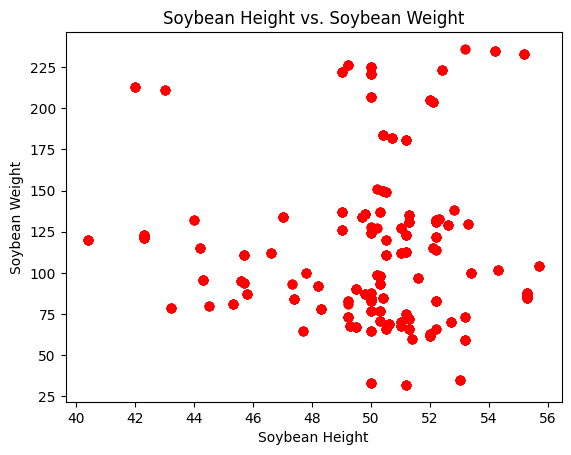

In [51]:
# Visualize the relationship between soybean height and soybean weight
import matplotlib.pyplot as plt

plt.scatter(soybean_dict['Height'], soybean_dict['Weight'], c = 'r')
plt.xlabel('Soybean Height')
plt.ylabel('Soybean Weight')
plt.title("Soybean Height vs. Soybean Weight")

## Writing Text to Files
We can create our own files and write information to them.

To write to a file, we must open a file using `open()`. To specify that we are writing to a file, we include the option `w`. The options for reading and appending to a file are `r` and `a`, respectively. The syntax for opening the file would be

`with open(file_name, 'w') as file:`

To write to a file, you can use `file.write('...')`.

Let's write some information from our soybean data to a file! We'll calculate the averages of the data columns from our soybean dictionary, then print that information to a file, which we can name `soybean_averages.txt`.

In [52]:
# Calculates the data averages
avg_height = sum(list(soybean_dict['Height']))/len(soybean_dict['Height'])
avg_pod_num = sum(list(soybean_dict['Pod Number']))/len(soybean_dict['Pod Number'])
avg_weight = sum(list(soybean_dict['Weight']))/len(soybean_dict['Weight'])

# Opens averages file
with open('soybean_averages.txt', 'w') as file:

    # Writes information to the file
    file.write("Soybean averages:\n")
    file.write(f"The average soybean height is {round(avg_height, 2)}.\n")
    file.write(f"The average soybean pod number is {round(avg_pod_num, 2)}.\n")
    file.write(f"The average soybean weight is {round(avg_weight, 2)}.\n")

We can view the file below using `more`.

In [53]:
!more soybean_averages.txt

Soybean averages:
The average soybean height is 49.93.
The average soybean pod number is 145.51.
The average soybean weight is 114.77.


## Reading Data From and Writing Data to Files

As of now, we have only been reading text from and writing text to files. However, you can also read and write data! This can be done using the package `json`. Json files contain data that can be read in and assigned to a dictionary.

To read in a json file as a dictionary, you can use the code

`json.load(file)`

and to write a dictionary to a json file, you can use the code

`json.dump(dict, file_object)`

Let's write our soybean dictionary to a json file, then try reading it in using json.

In [54]:
# Imports json package
import json

# Writes our soybean dictionary to a json file
with open('soybean_data.json', 'w') as file:
    json.dump(soybean_dict, file)

# Reads in the soybean data json
with open('soybean_data.json', 'r') as file:
    new_soybean_dict = json.load(file)

# Calculates the data averages from the new dictionary
avg_height = sum(list(new_soybean_dict['Height']))/len(new_soybean_dict['Height'])
avg_pod_num = sum(list(new_soybean_dict['Pod Number']))/len(new_soybean_dict['Pod Number'])
avg_weight = sum(list(new_soybean_dict['Weight']))/len(new_soybean_dict['Weight'])

# Prints out information about the loaded dictionary
print(f"The opened json file is {type(new_soybean_dict)}.")
print(f"The keys of the new dictionary are {new_soybean_dict.keys()}")
print(f"The average soybean height is {round(avg_height, 2)}.")
print(f"The average soybean pod number is {round(avg_pod_num, 2)}.")
print(f"The average soybean weight is {round(avg_weight, 2)}.")

The opened json file is <class 'dict'>.
The keys of the new dictionary are dict_keys(['Parameters', 'Height', 'Pod Number', 'Weight'])
The average soybean height is 49.93.
The average soybean pod number is 145.51.
The average soybean weight is 114.77.


As you can see, json preserves the data of dictionaries very well. Thus, it is a great option for saving data from Python.